In [2]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split the data into train and test sets
from sklearn.model_selection import train_test_split

# to build a linear regression model
from sklearn.linear_model import LinearRegression

# to check a regression model's performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
# disable warnings
warnings.filterwarnings("ignore")

In [3]:
# uncomment and run the following line if using Google Colab
# from google.colab import drive
# Write your code here to read the data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# loading data into a pandas dataframe
insurance = pd.read_csv('/content/drive/My Drive/insurance.csv')

In [ ]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
insurance.shape

(1338, 7)

In [ ]:
insurance.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
insurance.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [ ]:
insurance.duplicated().sum()

1

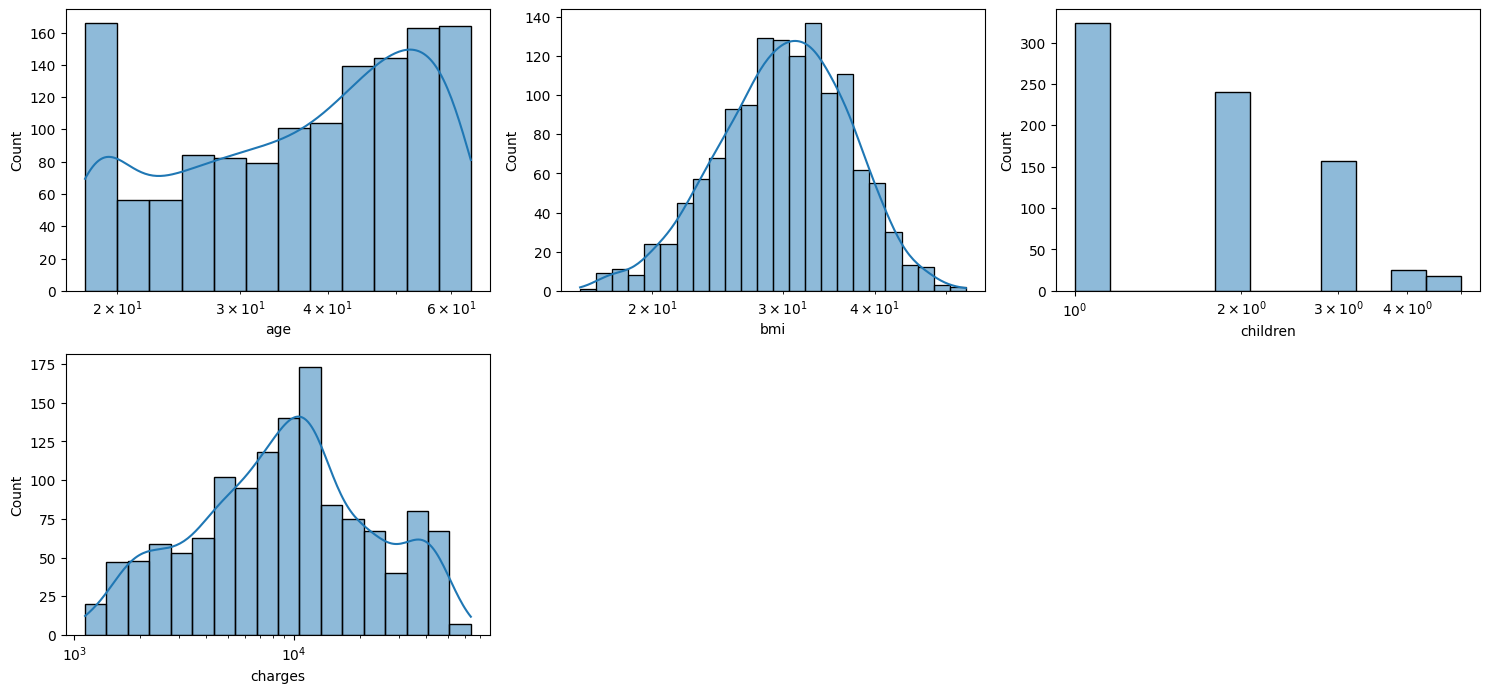

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
features = insurance.select_dtypes(include=['number']).columns.tolist()

# creating the histograms
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(insurance, log_scale=True, kde=True, x=feature)    # plot the histogram

plt.tight_layout()    # to add spacing between plots
plt.show()

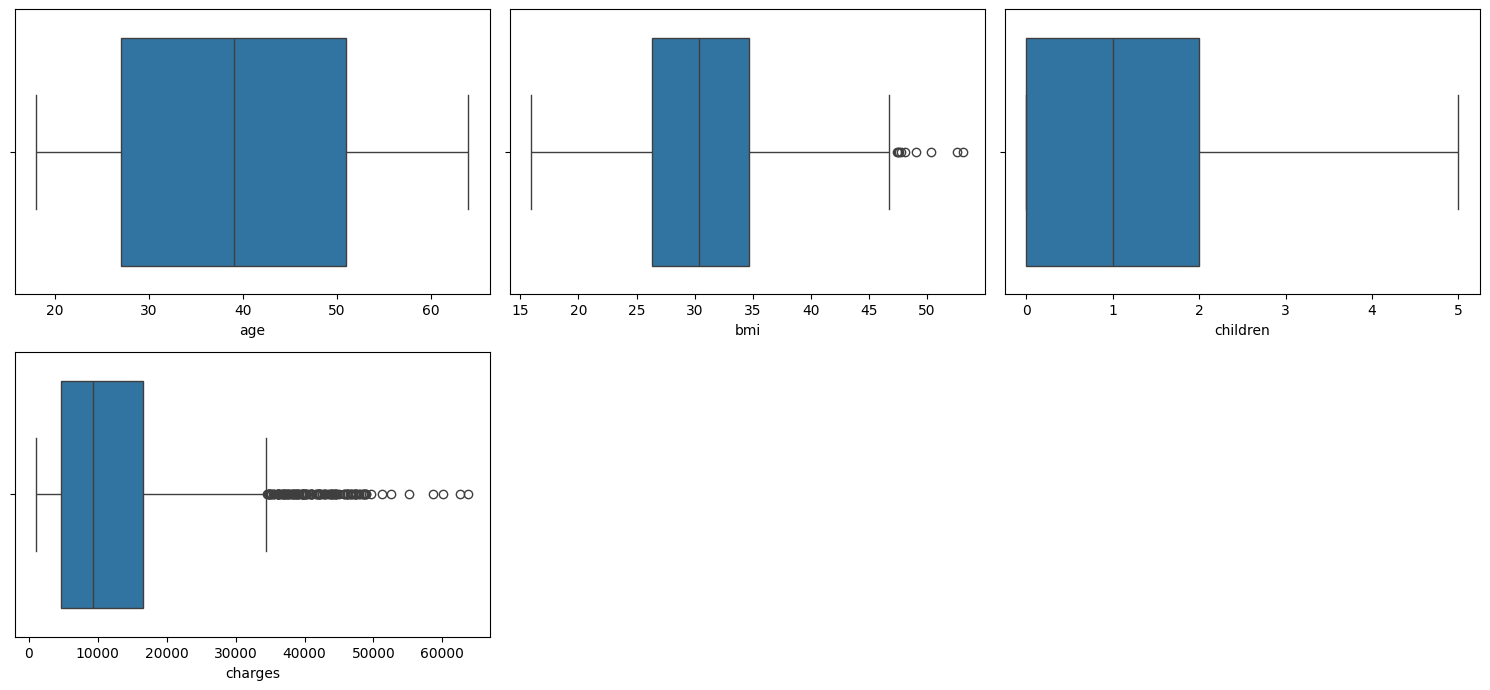

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
features = insurance.select_dtypes(include=['number']).columns.tolist()

# creating the histograms
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(insurance, x=feature)    # plot the histogram

plt.tight_layout()    # to add spacing between plots
plt.show()

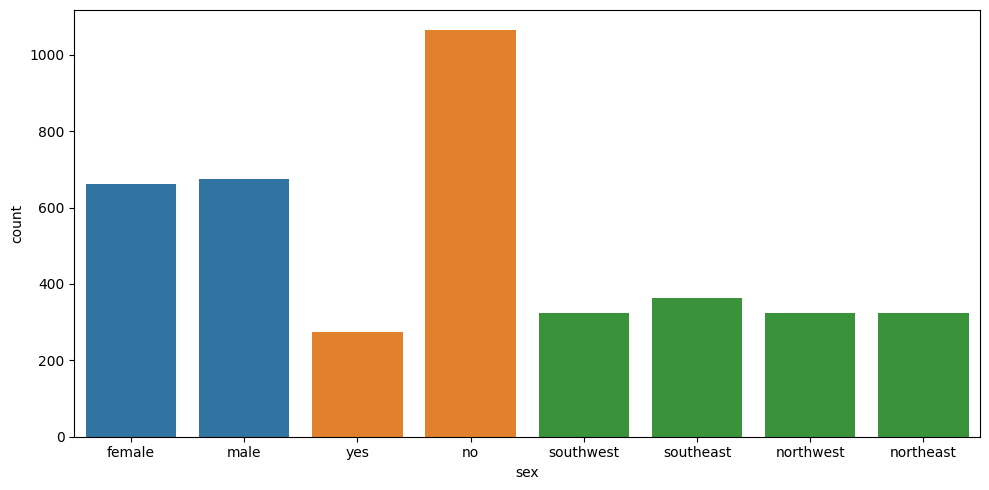

In [ ]:
# defining the figure size
plt.figure(figsize=(10, 5))

# defining the list of categorical features to plot
features = insurance.select_dtypes(exclude=['number']).columns.tolist()

# creating the histograms
for i, feature in enumerate(features):
    #plt.subplot(1, 2, i+1)    # assign a subplot in the main plot
    sns.countplot(insurance, x=feature)    # plot the histogram

plt.tight_layout()    # to add spacing between plots
plt.show()

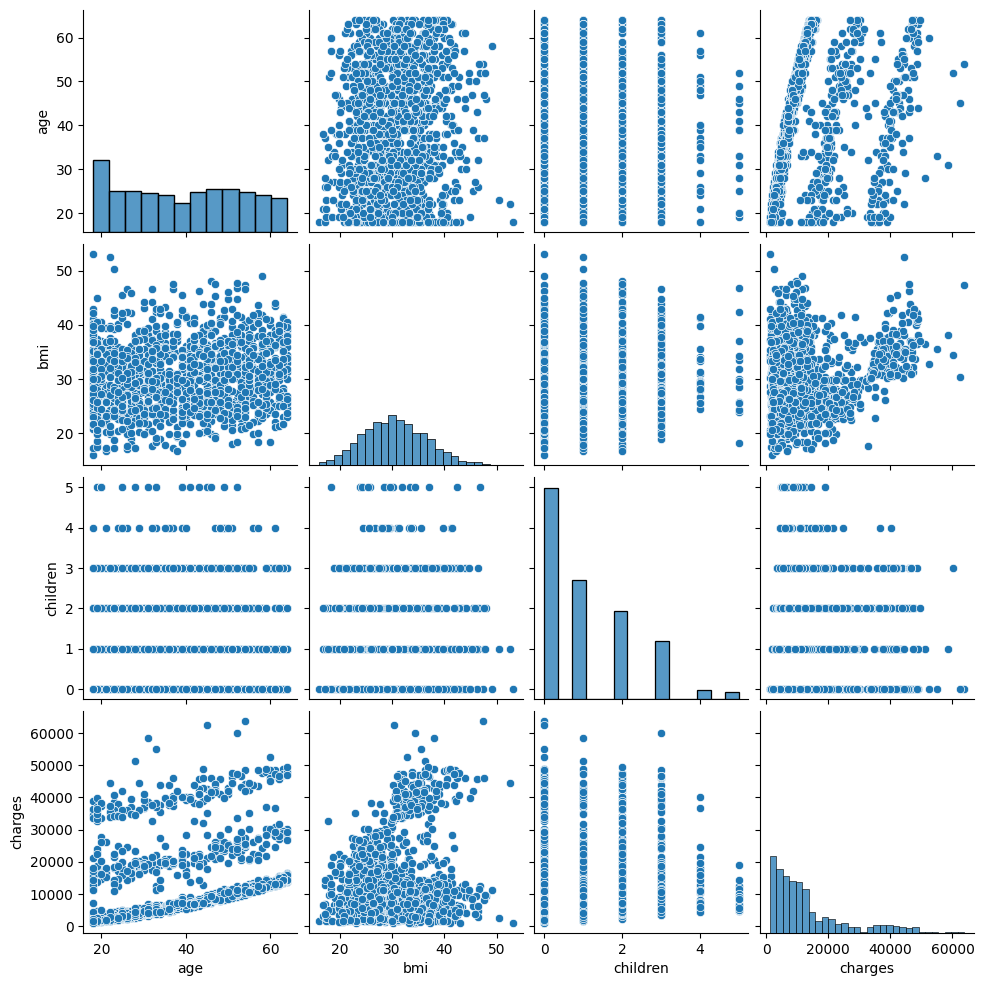

In [ ]:
sns.pairplot(insurance);

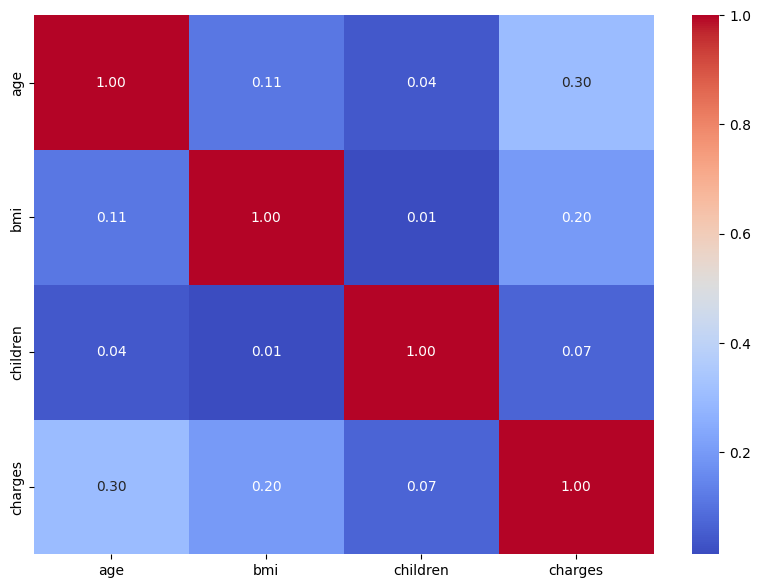

In [ ]:
# defining the figure size
plt.figure(figsize=(10, 7))

# plotting the correlation heatmap
sns.heatmap(insurance.corr(numeric_only = True), annot=True, fmt='0.2f', cmap='coolwarm');

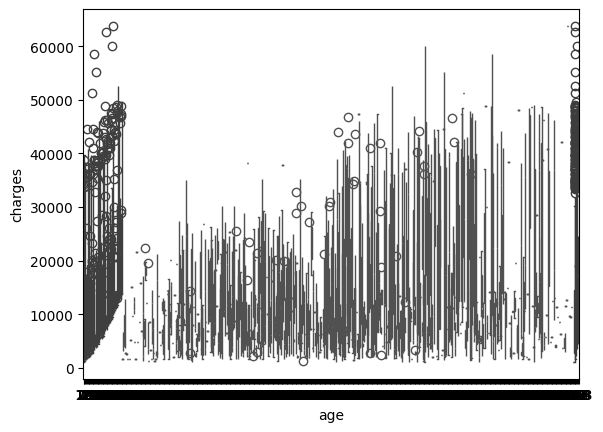

In [ ]:
sns.boxplot(insurance, y='charges', x='age');


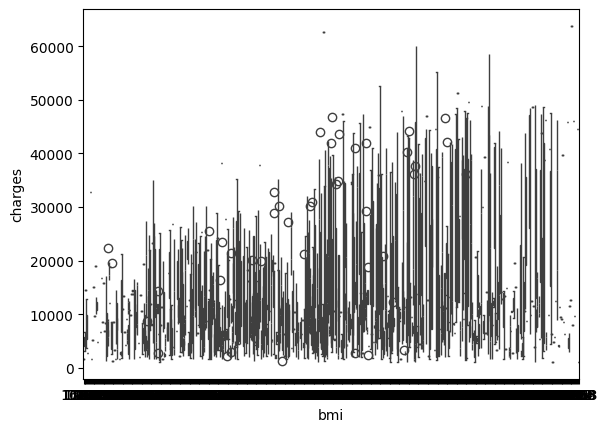

In [ ]:
sns.boxplot(insurance, y='charges', x='bmi');


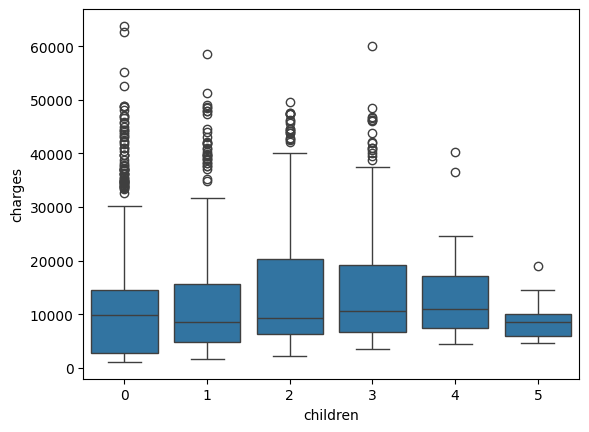

In [ ]:
sns.boxplot(insurance, y='charges', x='children');

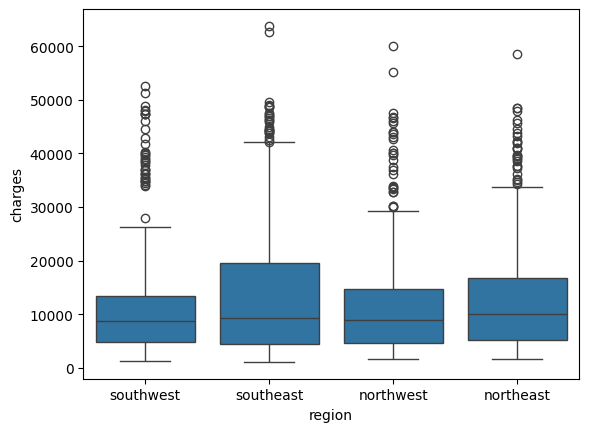

In [ ]:
sns.boxplot(insurance, y='charges', x='region');

In [ ]:
# defining the explanatory (independent) and response (dependent) variables
X = insurance.drop('charges', axis=1)
y = insurance['charges']

X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [ ]:
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [ ]:
# splitting the data in 70:30 ratio for train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,    # specifying the independent variables
    y,    # specifying the dependent variable
    test_size=0.30,    # specifying the size of the test set as a fraction of the whole data
    random_state=42    # specifying a seed value to enable reproducible results
)

In [ ]:
# creating one-hot encoded (also called dummy) variables
X = pd.get_dummies(
    X,    # defining the dataframe from where to fetch the data
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),    # defining the type of columns for which dummies will be made
    drop_first=True,    # dropping the first dummy column
)

# specifying the datatype of the independent variables dataframe
X = X.astype(float)

X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.0,27.900,0.0,0.0,1.0,0.0,0.0,1.0
1,18.0,33.770,1.0,1.0,0.0,0.0,1.0,0.0
2,28.0,33.000,3.0,1.0,0.0,0.0,1.0,0.0
3,33.0,22.705,0.0,1.0,0.0,1.0,0.0,0.0
4,32.0,28.880,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
# creating an instance of the linear regression model
lin_reg1 = LinearRegression()

# fitting the model to the training data
lin_reg1.fit(X_train, y_train)

LinearRegression()

In [ ]:
# printing the linear regression coefficients
print(
    "Coefficients:", lin_reg1.coef_, lin_reg1.intercept_
)

Coefficients: [  261.29692414   348.90691516   424.11912829   104.81182299
 23628.36722236  -486.93461047  -970.96883857  -926.32290791] -12373.963903035481


In [ ]:
# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100

# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regression model
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE
    r2 = r2_score(target, pred)  # to compute R-squared
    adj_r2 = adj_r2_score(predictors, target, pred)  # to compute Adjusted R-squared

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
            "R-squared": r2,
            "Adj R-squared": adj_r2,
        },
        index=[0],
    )

    return df_perf

In [ ]:
lin_reg1_train_perf = model_performance_regression(lin_reg1, X_train, y_train)
lin_reg1_train_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,6142.519819,4251.255799,43.235915,0.742398,0.740175
